###  Note: The main point of this project was just to write a script automating pulling data from CoinMarketCap's Free API and writing to a csv file (or could be loaded into a data warehouse), no subsequent analysis or data cleaning is done. Future projects more aligned with a business use case will include an end-to-end data solution

In [1]:
from requests import Request, Session
from requests.exceptions import ConnectionError, Timeout, TooManyRedirects
import json
import pandas as pd

## Writing Script we will use and then later incorporate into our actual automation to test that our pull requests work:

In [51]:
url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'

parameters = {
    'start': '1', #start from 1st listed coin
    'limit' : '15', #no more than 15 coins
    'convert' : 'USD' #want results in USD
}

headers = {
    'Accepts' : 'application/json', #want response in JSON format
    'X-CMC_PRO_API_KEY': 'a3722ce814904dabb9ccc4218e5b8d66' #our API key
}

session = Session() #init a session
session.headers.update(headers) #include our headers in session so we can be authentificated when requesting API pull


try:
    response = session.get(url, params= parameters) #request desired info, ie listed coins starting at the first one listed, then 4999 more
    data = json.loads(response.text) #parse JSON into native python object type (dict here as is typical)
    print(data)
except (ConnectionError, Timeout, TooManyRedirects) as e:
    print(e)

{'status': {'timestamp': '2025-11-18T15:30:14.756Z', 'error_code': 0, 'error_message': None, 'elapsed': 27, 'credit_count': 1, 'notice': None, 'total_count': 9189}, 'data': [{'id': 1, 'name': 'Bitcoin', 'symbol': 'BTC', 'slug': 'bitcoin', 'num_market_pairs': 12480, 'date_added': '2010-07-13T00:00:00.000Z', 'tags': ['mineable', 'pow', 'sha-256', 'store-of-value', 'state-channel', 'coinbase-ventures-portfolio', 'three-arrows-capital-portfolio', 'polychain-capital-portfolio', 'binance-labs-portfolio', 'blockchain-capital-portfolio', 'boostvc-portfolio', 'cms-holdings-portfolio', 'dcg-portfolio', 'dragonfly-capital-portfolio', 'electric-capital-portfolio', 'fabric-ventures-portfolio', 'framework-ventures-portfolio', 'galaxy-digital-portfolio', 'huobi-capital-portfolio', 'alameda-research-portfolio', 'a16z-portfolio', '1confirmation-portfolio', 'winklevoss-capital-portfolio', 'usv-portfolio', 'placeholder-ventures-portfolio', 'pantera-capital-portfolio', 'multicoin-capital-portfolio', 'para

In [26]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [8]:
#Displaying our pulled data in a Dataframe:
df = pd.json_normalize(data['data'])
df['timestamp'] = pd.to_datetime('now') #Adding timestamp to know when exactly our API pull iteration ran
df

,id,name,symbol,slug,num_market_pairs,date_added,tags,max_supply,circulating_supply,total_supply,infinite_supply,platform,cmc_rank,self_reported_circulating_supply,self_reported_market_cap,tvl_ratio,last_updated,quote.USD.price,quote.USD.volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.name,platform.symbol,platform.slug,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,12473,2010-07-13T00:00:00.000Z,"[mineable, pow, sha-256, store-of-value, state...",2.100000e+07,1.994877e+07,1.994877e+07,False,NaN,1,NaN,NaN,None,2025-11-14T19:05:00.000Z,94888.418556,1.191325e+11,30.6321,-0.892168,-3.801270,-7.403262,-14.789879,-17.837983,-19.416003,1.892907e+12,58.5631,1.992657e+12,None,2025-11-14T19:05:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-11-14 14:06:55.043732
1,1027,Ethereum,ETH,ethereum,11147,2015-08-07T00:00:00.000Z,"[pos, smart-contracts, ethereum-ecosystem, coi...",NaN,1.206964e+08,1.206964e+08,True,NaN,2,NaN,NaN,None,2025-11-14T19:05:00.000Z,3163.196771,5.089665e+10,11.1787,-0.333424,-1.650784,-7.417011,-20.888347,-29.867040,-28.343965,3.817863e+11,11.8118,3.817863e+11,None,2025-11-14T19:05:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-11-14 14:06:55.043732
2,825,Tether USDt,USDT,tether,158351,2015-02-25T00:00:00.000Z,"[stablecoin, asset-backed-stablecoin, usd-stab...",NaN,1.840651e+11,1.869128e+11,True,NaN,3,NaN,NaN,None,2025-11-14T19:05:00.000Z,1.000056,1.894232e+11,25.6557,0.069436,-0.001249,0.066023,-0.035886,-0.025437,-0.060501,1.840755e+11,5.6950,1.869233e+11,None,2025-11-14T19:05:00.000Z,1027.0,Ethereum,ETH,ethereum,0xdac17f958d2ee523a2206206994597c13d831ec7,2025-11-14 14:06:55.043732
3,52,XRP,XRP,xrp,1759,2013-08-04T00:00:00.000Z,"[medium-of-exchange, enterprise-solutions, xrp...",1.000000e+11,6.010720e+10,9.998577e+10,False,NaN,4,NaN,NaN,None,2025-11-14T19:05:00.000Z,2.285915,7.830876e+09,17.3576,-0.855989,-2.305550,-1.934937,-6.219158,-24.112914,-26.312500,1.374000e+11,4.2509,2.285915e+11,None,2025-11-14T19:05:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-11-14 14:06:55.043732
4,1839,BNB,BNB,bnb,2964,2017-07-25T00:00:00.000Z,"[marketplace, centralized-exchange, payments, ...",1.377370e+08,1.377370e+08,1.377370e+08,False,NaN,5,NaN,NaN,None,2025-11-14T19:06:00.000Z,920.312356,4.046484e+09,54.1414,-0.168804,0.299335,-5.896204,-21.278457,-0.155879,10.174211,1.267611e+11,3.9218,1.267611e+11,None,2025-11-14T19:06:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-11-14 14:06:55.043732
5,5426,Solana,SOL,solana,1050,2020-04-10T00:00:00.000Z,"[pos, platform, solana-ecosystem, cms-holdings...",NaN,5.540289e+08,6.139614e+08,True,NaN,6,5.252369e+08,7.417180e+10,None,2025-11-14T19:05:00.000Z,141.215899,9.194012e+09,48.1299,-0.014758,-2.837941,-12.743031,-28.492613,-39.631651,-25.006365,7.823769e+10,2.4205,8.670111e+10,None,2025-11-14T19:05:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-11-14 14:06:55.043732
6,3408,USDC,USDC,usd-coin,34522,2018-10-08T00:00:00.000Z,"[medium-of-exchange, stablecoin, asset-backed-...",NaN,7.526296e+10,7.526296e+10,False,NaN,7,6.090122e+10,6.091522e+10,None,2025-11-14T19:05:00.000Z,1.000230,2.445493e+10,38.0446,0.036434,0.018170,0.036968,0.033991,0.014231,0.025865,7.528025e+10,2.3290,7.528025e+10,None,2025-11-14T19:05:00.000Z,1027.0,Ethereum,ETH,ethereum,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2025-11-14 14:06:55.043732
7,1958,TRON,TRX,tron,1259,2017-09-13T00:00:00.000Z,"[media, payments, tron-ecosystem, layer-1, dwf...",NaN,9.466859e+10,9.466858e+10,True,NaN,8,9.466789e+10,2.793084e+10,None,2025-11-14T19:06:00.000Z,0.295040,1.274227e+09,51.3843,0.068525,0.734365,1.068005,-7.122406,-14.192646,-15.224371,2.793105e+10,0.8641,2.793105e+10,None,2025-11-14T19:06:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-11-14 14:06:55.043732
8,74,Dogecoin,DOGE,dogecoin,1347,2013-12-15T00:00

### Function definition to pull info from API, and update our dataframe with the current timestamp:

In [13]:
def api_runner(df):
    url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'

    parameters = {
        'start': '1', #start from 1st listed coin
        'limit' : '15', #no more than 100 coins
        'convert' : 'USD' #want results in USD
    }
    
    headers = {
        'Accepts' : 'application/json', #want response in JSON format
        'X-CMC_PRO_API_KEY': 'a3722ce814904dabb9ccc4218e5b8d66' #our API key
    }
    
    session = Session() #init a session
    session.headers.update(headers) #include our headers in session so we can be authentificated when requesting API pull
    
    
    try:
        response = session.get(url, params= parameters) #request desired info, ie listed coins starting at the first one listed, then 4999 more
        data = json.loads(response.text) #parse JSON into native python object type (dict here as is typical)
        
    except (ConnectionError, Timeout, TooManyRedirects) as e:
        print(e)

    #Store in a dataframe:
    df = pd.json_normalize(data['data'])
    #Add our timestamp column:
    df['timestamp'] = pd.to_datetime('now')
    
    #Writing pulled data to a csv
    if not os.path.isfile(r'C:\Users\jules\Downloads\Crypto API Project\Crypto_API_pull.csv'):
        df.to_csv(r'C:\Users\jules\Downloads\Crypto API Project\Crypto_API_pull.csv', header = 'column_names')
    else:
        df.to_csv(r'C:\Users\jules\Downloads\Crypto API Project\Crypto_API_pull.csv', mode = 'a', header = False)
    return df
    
    #If we want to store the pulls directly into a DataFrame, can do the following:
    df_append = pd.DataFrame(df2)
    df = pd.concat([df,df_append], ignore_index=True)

   

### Automating:

In [14]:
import os
from time import time
from time import sleep


#Creating our loop
df = pd.DataFrame() #Could also define df as a global variable (using global df) at the beginning of the api_runner function
for i in range(1000): #Note: Crypto API free version allows for 333 requests per day
    df = api_runner(df) #run our function
    print(f'API Runner pull {i} completed successfully')
    sleep(600) #sleep for 10 minutes


API Runner pull 0 completed successfully
API Runner pull 1 completed successfully


### Note: Above output interrupted to show that the code works and the csv file looks as it should

In [17]:
#Checking our output csv file to see if our script works:
result_df = pd.read_csv('C:\\Users\\jules\\Downloads\\Crypto API Project\\Crypto_API_pull.csv')
result_df

,Unnamed: 0,id,name,symbol,slug,num_market_pairs,date_added,tags,max_supply,circulating_supply,...,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.name,platform.symbol,platform.slug,platform.token_address,timestamp
0,0,1,Bitcoin,BTC,bitcoin,12474,2010-07-13T00:00:00.000Z,"['mineable', 'pow', 'sha-256', 'store-of-value...",2.100000e+07,1.994881e+07,...,58.8529,2.021784e+12,NaN,2025-11-15T15:58:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-11-15 11:00:27.453179
1,1,1027,Ethereum,ETH,ethereum,11154,2015-08-07T00:00:00.000Z,"['pos', 'smart-contracts', 'ethereum-ecosystem...",NaN,1.206963e+08,...,11.7863,3.846291e+11,NaN,2025-11-15T15:58:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-11-15 11:00:27.453179
2,2,825,Tether USDt,USDT,tether,158402,2015-02-25T00:00:00.000Z,"['stablecoin', 'asset-backed-stablecoin', 'usd...",NaN,1.840242e+11,...,5.6361,1.868065e+11,NaN,2025-11-15T15:58:00.000Z,1027.0,Ethereum,ETH,ethereum,0xdac17f958d2ee523a2206206994597c13d831ec7,2025-11-15 11:00:27.453179
3,3,52,XRP,XRP,xrp,1759,2013-08-04T00:00:00.000Z,"['medium-of-exchange', 'enterprise-solutions',...",1.000000e+11,6.017900e+10,...,4.1599,2.255837e+11,NaN,2025-11-15T15:58:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-11-15 11:00:27.453179
4,4,1839,BNB,BNB,bnb,2965,2017-07-25T00:00:00.000Z,"['marketplace', 'centralized-exchange', 'payme...",1.377370e+08,1.377370e+08,...,3.9530,1.290002e+11,NaN,2025-11-15T15:59:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-11-15 11:00:27.453179
5,5,5426,Solana,SOL,solana,1050,2020-04-10T00:00:00.000Z,"['pos', 'platform', 'solana-ecosystem', 'cms-h...",NaN,5.541835e+08,...,2.4092,8.712074e+10,NaN,2025-11-15T15:58:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-11-15 11:00:27.453179
6,6,3408,USDC,USDC,usd-coin,34541,2018-10-08T00:00:00.000Z,"['medium-of-exchange', 'stablecoin', 'asset-ba...",NaN,7.492185e+10,...,2.2957,7.491542e+10,NaN,2025-11-15T15:58:00.000Z,1027.0,Ethereum,ETH,ethereum,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2025-11-15 11:00:27.453179
7,7,1958,TRON,TRX,tron,1259,2017-09-13T00:00:00.000Z,"['media', 'payments', 'tron-ecosystem', 'layer...",NaN,9.466974e+10,...,0.8500,2.773726e+10,NaN,2025-11-15T15:58:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-11-15 11:00:27.453179
8,8,74,Dogecoin,DOGE,dogecoin,1347,2013-12-15T00:00:00.000Z,"['mineable', 'pow', 'scrypt', 'medium-of-excha...",NaN,1.517844e+11,...,0.7593,2.477740e+10,NaN,2025-11-15T15:58:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-11-15 11:00:27.453179
9,9,2010,Cardano,ADA,cardano,1626,2017-10-01T00:00:00.000Z,"['dpos', 'pos', 'platform', 'research', 'smart...",4.500000e+10,3.587106e+10,...,0.5580,2.284244e+10,NaN,2025-11-15T15:58:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-11-15 11:00:27.453179


### Quickly removing scientific notation where applicable:

In [18]:
pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [19]:
result_df

,Unnamed: 0,id,name,symbol,slug,num_market_pairs,date_added,tags,max_supply,circulating_supply,...,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.name,platform.symbol,platform.slug,platform.token_address,timestamp
0,0,1,Bitcoin,BTC,bitcoin,12474,2010-07-13T00:00:00.000Z,"['mineable', 'pow', 'sha-256', 'store-of-value...",21000000.00000,19948812.00000,...,58.85290,2021784305255.79004,NaN,2025-11-15T15:58:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-11-15 11:00:27.453179
1,1,1027,Ethereum,ETH,ethereum,11154,2015-08-07T00:00:00.000Z,"['pos', 'smart-contracts', 'ethereum-ecosystem...",NaN,120696252.13113,...,11.78630,384629058812.08002,NaN,2025-11-15T15:58:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-11-15 11:00:27.453179
2,2,825,Tether USDt,USDT,tether,158402,2015-02-25T00:00:00.000Z,"['stablecoin', 'asset-backed-stablecoin', 'usd...",NaN,184024212275.56512,...,5.63610,186806501412.75000,NaN,2025-11-15T15:58:00.000Z,1027.00000,Ethereum,ETH,ethereum,0xdac17f958d2ee523a2206206994597c13d831ec7,2025-11-15 11:00:27.453179
3,3,52,XRP,XRP,xrp,1759,2013-08-04T00:00:00.000Z,"['medium-of-exchange', 'enterprise-solutions',...",100000000000.00000,60179002978.00000,...,4.15990,225583700667.78000,NaN,2025-11-15T15:58:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-11-15 11:00:27.453179
4,4,1839,BNB,BNB,bnb,2965,2017-07-25T00:00:00.000Z,"['marketplace', 'centralized-exchange', 'payme...",137737006.55000,137737006.55000,...,3.95300,129000150364.94000,NaN,2025-11-15T15:59:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-11-15 11:00:27.453179
5,5,5426,Solana,SOL,solana,1050,2020-04-10T00:00:00.000Z,"['pos', 'platform', 'solana-ecosystem', 'cms-h...",NaN,554183493.08635,...,2.40920,87120737536.00000,NaN,2025-11-15T15:58:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-11-15 11:00:27.453179
6,6,3408,USDC,USDC,usd-coin,34541,2018-10-08T00:00:00.000Z,"['medium-of-exchange', 'stablecoin', 'asset-ba...",NaN,74921849161.28743,...,2.29570,74915424927.46001,NaN,2025-11-15T15:58:00.000Z,1027.00000,Ethereum,ETH,ethereum,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2025-11-15 11:00:27.453179
7,7,1958,TRON,TRX,tron,1259,2017-09-13T00:00:00.000Z,"['media', 'payments', 'tron-ecosystem', 'layer...",NaN,94669743596.57430,...,0.85000,27737256407.35000,NaN,2025-11-15T15:58:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-11-15 11:00:27.453179
8,8,74,Dogecoin,DOGE,dogecoin,1347,2013-12-15T00:00:00.000Z,"['mineable', 'pow', 'scrypt', 'medium-of-excha...",NaN,151784416383.70523,...,0.75930,24777403135.81000,NaN,2025-11-15T15:58:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-11-15 11:00:27.453179
9,9,2010,Cardano,ADA,cardano,1626,2017-10-01T00:00:00.000Z,"['dpos', 'pos', 'platform', 'research', 'smart...",45000000000.00000,35871059005.02065,...,0.55800,22842444744.50000,NaN,2025-11-15T15:58:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-11-15 11:00:27.453179


### Making a quick visual of percent change in price over various time periods:

In [23]:
pct_change_df = result_df.groupby(by = 'name', sort = False)[['quote.USD.percent_change_1h',
       'quote.USD.percent_change_24h', 'quote.USD.percent_change_7d',
       'quote.USD.percent_change_30d', 'quote.USD.percent_change_60d',
       'quote.USD.percent_change_90d']].mean()
pct_change_df

,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d
name,,,,,,
Bitcoin,0.11143,-0.52849,-5.27561,-11.27786,-16.87324,-18.62909
Ethereum,0.30806,-0.15326,-5.58001,-18.30460,-28.67418,-30.18135
Tether USDt,0.00105,0.02268,-0.02796,-0.09643,-0.06210,-0.10076
XRP,-0.13059,-2.58429,0.08975,-4.08469,-25.78877,-28.28064
BNB,0.07876,1.20404,-5.48262,-17.50496,-0.11561,8.82674
Solana,0.38197,-0.33448,-9.32413,-24.22771,-40.24840,-27.37243
USDC,0.00144,0.00856,-0.00184,-0.00995,0.01340,0.00020
TRON,0.01378,-0.92660,0.74207,-7.95067,-14.04074,-16.80318
Dogecoin,-0.21252,0.12613,-6.09452,-13.72466,-38.68825,-32.57421


In [28]:
pct_change_stack = pct_change_df.stack()
pct_change_stack_df = pct_change_stack.to_frame(name = 'values')
pct_change_stack_df

values
name                                                
Bitcoin      quote.USD.percent_change_1h     0.11143
             quote.USD.percent_change_24h   -0.52849
             quote.USD.percent_change_7d    -5.27561
             quote.USD.percent_change_30d  -11.27786
             quote.USD.percent_change_60d  -16.87324
             quote.USD.percent_change_90d  -18.62909
Ethereum     quote.USD.percent_change_1h     0.30806
             quote.USD.percent_change_24h   -0.15326
             quote.USD.percent_change_7d    -5.58001
             quote.USD.percent_change_30d  -18.30460
             quote.USD.percent_change_60d  -28.67418
             quote.USD.percent_change_90d  -30.18135
Tether USDt  quote.USD.percent_change_1h     0.00105
             quote.USD.percent_change_24h    0.02268
             quote.USD.percent_change_7d    -0.02796
             quote.USD.percent_change_30d   -0.09643
             quote.USD.percent_change_60d   -0.06210
             quote.USD.percent_change_90d   -0.10076
XRP          quote.USD.percent_change_1h    -0.13059
             quote.USD.percent_change_24h   -2.58429
             quote.USD.percent_change_7d     0.08975
             quote.USD.percent_change_30d   -4.08469
             quote.USD.percent_change_60d  -25.78877
             quote.USD.percent_change_90d  -28.28064
BNB          quote.USD.percent_change_1h     0.07876
             quote.USD.percent_change_24h    1.20404
             quote.USD.percent_change_7d    -5.48262
             quote.USD.percent_change_30d  -17.50496
             quote.USD.percent_change_60d   -0.11561
             quote.USD.percent_change_90d    8.82674
Solana       quote.USD.percent_change_1h     0.38197
             quote.USD.percent_change_24h   -0.33448
             quote.USD.percent_change_7d    -9.32413
             quote.USD.percent_change_30d  -24.22771
             quote.USD.percent_change_60d  -40.24840
             quote.USD.percent_change_90d  -27.37243
USDC         quote.USD.percent_change_1h     0.00144
             quote.USD.percent_change_24h    0.00856
             quote.USD.percent_change_7d    -0.00184
             quote.USD.percent_change_30d   -0.00995
             quote.USD.percent_change_60d    0.01340
             quote.USD.percent_change_90d    0.00020
TRON         quote.USD.percent_change_1h     0.01378
             quote.USD.percent_change_24h   -0.92660
             quote.USD.percent_change_7d     0.74207
             quote.USD.percent_change_30d   -7.95067
             quote.USD.percent_change_60d  -14.04074
             quote.USD.percent_change_90d  -16.80318
Dogecoin     quote.USD.percent_change_1h    -0.21252
             quote.USD.percent_change_24h    0.12613
             quote.USD.percent_change_7d    -6.09452
             quote.USD.percent_change_30d  -13.72466
             quote.USD.percent_change_60d  -38.68825
             quote.USD.percent_change_90d  -32.57421
Cardano      quote.USD.percent_change_1h    -0.04746
             quote.USD.percent_change_24h   -1.39678
             quote.USD.percent_change_7d    -8.88982
             quote.USD.percent_change_30d  -22.04419
             quote.USD.percent_change_60d  -41.62372
             quote.USD.percent_change_90d  -47.97691
Hyperliquid  quote.USD.percent_change_1h     0.88581
             quote.USD.percent_change_24h    3.29610
             quote.USD.percent_change_7d    -2.32296
             quote.USD.percent_change_30d    5.62048
             quote.USD.percent_change_60d  -27.35608
             quote.USD.percent_change_90d  -16.66610
Zcash        quote.USD.percent_change_1h    -2.16908
             quote.USD.percent_change_24h   14.28759
             quote.USD.percent_change_7d    31.36017
             quote.USD.percent_change_30d  205.09154
             quote.USD.percent_change_60d 1202.35324
             quote.USD.percent_change_90d 1681.36198
Bitcoin Cash quote.USD.percent_change_1h    -0.05542
             quote.USD.percent_change_24h    2.90774
             quote

In [29]:
pct_change_stack_df.count()

values    90
dtype: int64

In [32]:
df_pct_change = pct_change_stack_df.reset_index()
df_pct_change

,name,level_1,values
0,Bitcoin,quote.USD.percent_change_1h,0.11143
1,Bitcoin,quote.USD.percent_change_24h,-0.52849
2,Bitcoin,quote.USD.percent_change_7d,-5.27561
3,Bitcoin,quote.USD.percent_change_30d,-11.27786
4,Bitcoin,quote.USD.percent_change_60d,-16.87324
5,Bitcoin,quote.USD.percent_change_90d,-18.62909
6,Ethereum,quote.USD.percent_change_1h,0.30806
7,Ethereum,quote.USD.percent_change_24h,-0.15326
8,Ethereum,quote.USD.percent_change_7d,-5.58001
9,Ethereum,quote.USD.percent_change_30d,-18.30460


In [37]:
df_pct_change.rename(columns = {'level_1' : 'pct_change'}, inplace= True)

In [38]:
df_pct_change

,name,pct_change,values
0,Bitcoin,quote.USD.percent_change_1h,0.11143
1,Bitcoin,quote.USD.percent_change_24h,-0.52849
2,Bitcoin,quote.USD.percent_change_7d,-5.27561
3,Bitcoin,quote.USD.percent_change_30d,-11.27786
4,Bitcoin,quote.USD.percent_change_60d,-16.87324
5,Bitcoin,quote.USD.percent_change_90d,-18.62909
6,Ethereum,quote.USD.percent_change_1h,0.30806
7,Ethereum,quote.USD.percent_change_24h,-0.15326
8,Ethereum,quote.USD.percent_change_7d,-5.58001
9,Ethereum,quote.USD.percent_change_30d,-18.30460


In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

In [47]:
# Before making a visual, going to clean up pct_change column names to avoid label clutter on x-axis:
df_pct_change['pct_change'] = df_pct_change['pct_change'].map(
    {'quote.USD.percent_change_1h': '1h',
    'quote.USD.percent_change_24h' : '24h',
    'quote.USD.percent_change_7d': '7d',
    'quote.USD.percent_change_30d': '30d',
    'quote.USD.percent_change_60d' : '60d',
    'quote.USD.percent_change_90d': '90d'}
)

<Figure size 1200x600 with 0 Axes>

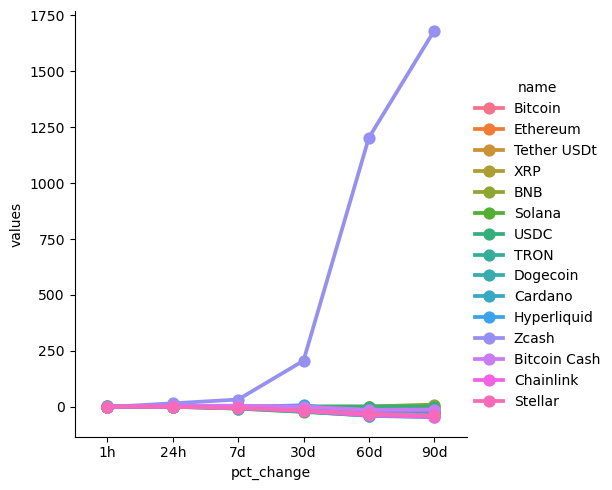

In [49]:
plt.figure(figsize=(12,6))
sns.catplot(data = df_pct_change, x = 'pct_change', y = 'values', hue = 'name', kind = 'point')

### Excluding Zcash to get a more granular look at the rest of the coins:

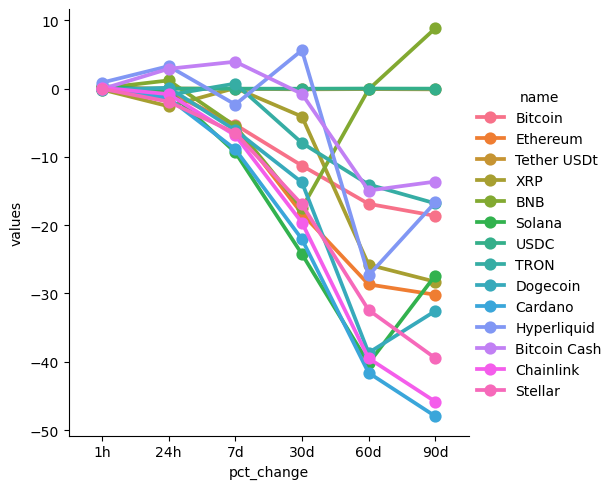

In [50]:
df_pct_change_no_outlier = df_pct_change[df_pct_change['name'] != 'Zcash']
sns.catplot(data = df_pct_change_no_outlier, x = 'pct_change', y = 'values', hue = 'name', kind = 'point')

### Note: could also only include top 5 or so coins to get a look at the most important ones